# 04 - Método da bisseção
Vamos aprender sobre como usar o método da bisseção para encontrar as raízes de funções reais.

Crie uma nova branch (versão) do repositório:

```bash
git branch semana4
```

Faça o checkout nessa nova branch:

```bash
git checkout semana4
```

A partir desta atividade, os arquivos de algoritmos ficarão dentro da pasta utils.

```txt
├─ utils/
│   └─ __init__.py
│   └─ algoritmos.py
```

<hr />

## Atividade 1
Escreva o método da bisseção dentro do arquivo $utils/algoritmos.py$.

In [2]:
def bissecao(f,     # função que queremos encontrar a raiz
              a,    # a início do intervalo
              b,    # b fim do intervalo
              TOL,   # erro tolerado
              iter=16):  # número máximo de iterações
    c = (a + b) / 2  # ponto médio entre os valores a e b
    if f(a) * f(b) > 0:
        raise ValueError("Nenhuma raiz encontrada no intervalo.")
    else:
        i = 0  # variável contador
        ERRO = abs(f(b) - f(a))  # diferença entre os valores de y

        while ERRO > TOL and i < iter:  # loop iterativo com parada
            c = (a + b) / 2.0
            if f(c) == 0:
                return c, i
            elif f(a) * f(c) < 0:
                b = c
            else:
                a = c
            i += 1
            ERRO = abs(f(b) - f(a))
        return c, i

Importe e teste a função:  

$$
f(x) = x^3 - x - 2
$$

Em que os valores iniciais a e b são obtidos graficamente.

In [3]:
%pip install numpy matplotlib

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/3a/5f/62d28cf019460c7f1394105b4d49d9911a9c444cb77ab0bd95a204c5a6de/numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/c9/cf/b4ad2cc81b6672ea29ea04e64e350a9f9b493b0908ccd884c67eeff8f7b2/matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.6 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/cc/8f/ec6289987824b29529d0dfda0d74a07cec60e54b9c92f3c9da4c0ac732de/contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3

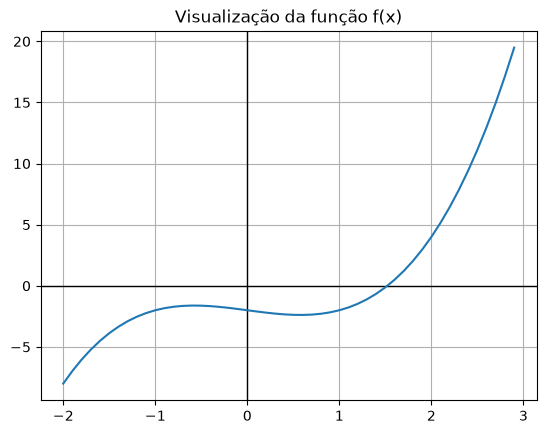

raiz = 1.5213775634765625 , i = 16


In [4]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

# Sobe um nível para a raiz do projeto e adiciona ao caminho do sistema
sys.path.append(os.path.abspath(os.path.join('..')))

# Agora você importa suas ferramentas da pasta utils
from utils.algoritmos import bissecao

# Definição da função
def f(x):
    return x**3 - x - 2

def plot(f, number=1):
    # Intervalo para plotar
    x_vals = np.arange(-2, 3, 0.1)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")
    plt.show()
    plt.close()

def main():
    plot(f, 1)
    r, i = bissecao(f, 1, 2, 1e-15)
    print(f"raiz = {r} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 2
Considere a equação  

$$
\sqrt{x} = \cos(x).
$$  

Use o método da bisseção com intervalo inicial obtido por gráfico (entre 0 e 1) para calcular um valor aproximado com precisão de $10^{-4}$ para no máximo 4 iterações.

**Resposta:**  
$
x \approx 0.6875
$ 

In [6]:
import math


def f(x):
    return math.sqrt(x) - math.cos(x)


def bissecao(f, a, b, TOL, iter=16):
    c = (a + b) / 2
    if f(a) * f(b) > 0:
        raise ValueError("Nenhuma raiz encontrada no intervalo.")
    else:
        i = 0
        ERRO = abs(f(b) - f(a))

        while ERRO > TOL and i < iter:
            c = (a + b) / 2.0
            if f(c) == 0:
                return c, i
            elif f(a) * f(c) < 0:
                b = c
            else:
                a = c
            i += 1
            ERRO = abs(f(b) - f(a))
        return c, i


def main():
    a = 0.0
    b = 1.0
    TOL = 1e-4
    max_iter = 4

    raiz, num_iter = bissecao(f, a, b, TOL, iter=max_iter)

    print(f"Raiz encontrada: x ≈ {raiz}")
    print(f"Número de iterações executadas: {num_iter}")


if __name__ == "__main__":
    main()

Raiz encontrada: x ≈ 0.6875
Número de iterações executadas: 4


## Atividade 3
Trace o gráfico e isole as três primeiras raízes positivas da função:  

$$
f(x) = 5\sin(x^2) - \exp\!\left(\frac{x}{10}\right)
$$  

em intervalos de comprimento $(0.1)$. Então, use o método da bisseção para obter aproximações dos zeros com precisão de $10^{-5}$.  

**Resposta:**  

- Intervalo $(0.4, 0.5)$, zero em $(x \approx 0.45931)$.  
- Intervalo $(1.7, 1.8)$, zero em $(x \approx 1.7036)$.  
- Intervalo $(2.5, 2.6)$, zero em $(x \approx 2.5582)$. 

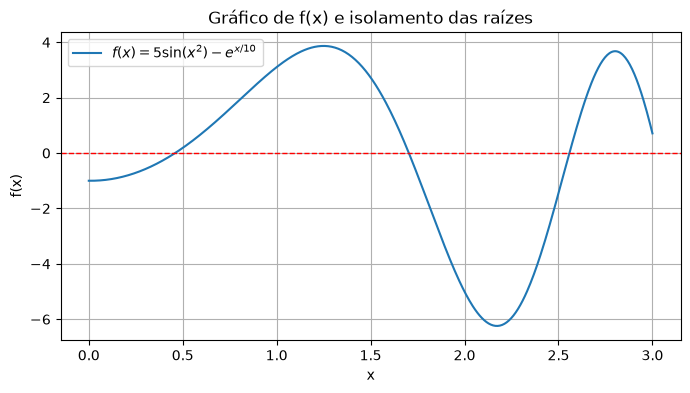

   Intervalo | Aproximação da Raiz (x) |  Iterações
----------------------------------------------------
  (0.4, 0.5) |                 0.45931 |         16
  (1.7, 1.8) |                 1.70357 |         18
  (2.5, 2.6) |                 2.55821 |         18


In [7]:
import math
import matplotlib.pyplot as plt
import numpy as np


def f(x: float) -> float:
    return 5 * math.sin(x**2) - math.exp(x / 10)


def bissecao(f, a, b, TOL, iter=100):
    c = (a + b) / 2
    if f(a) * f(b) > 0:
        raise ValueError("Nenhuma raiz encontrada no intervalo.")
    else:
        i = 0
        ERRO = abs(f(b) - f(a))

        while ERRO > TOL and i < iter:
            c = (a + b) / 2.0
            if f(c) == 0:
                return c, i
            elif f(a) * f(c) < 0:
                b = c
            else:
                a = c
            i += 1
            ERRO = abs(f(b) - f(a))
        return c, i


def main():
    # 1. Traçar o gráfico
    x_vals = np.linspace(0, 3, 500)
    y_vals = [f(x) for x in x_vals]

    plt.figure(figsize=(8, 4))
    plt.plot(x_vals, y_vals, label=r"$f(x) = 5\sin(x^2) - e^{x/10}$")
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.title("Gráfico de f(x) e isolamento das raízes")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 2. Intervalos de comprimento 0.1 especificados
    intervalos = [(0.4, 0.5), (1.7, 1.8), (2.5, 2.6)]
    TOL = 1e-5

    print(
        f"{'Intervalo':>12} | {'Aproximação da Raiz (x)':>23} | {'Iterações':>10}"
    )
    print("-" * 52)

    for a, b in intervalos:
        raiz, num_iter = bissecao(f, a, b, TOL)
        print(f"({a:.1f}, {b:.1f})".rjust(12) + f" | {raiz:23.5f} | {num_iter:10d}")


if __name__ == "__main__":
    main()

## Atividade 4
O desenho abaixo mostra um circuito não linear envolvendo uma fonte de tensão constante, um diodo retificador e um resistor.  

Sabendo que a relação entre a corrente ($I_d$) e a tensão ($v_d$) no diodo é dada pela seguinte expressão:

$ I_d = I_R \left( \exp\left(\tfrac{v_d}{v_t}\right) - 1 \right) $

onde $I_R$ é a corrente de condução reversa e $v_t$ a tensão térmica, dada por  

$ v_t = \tfrac{kT}{q} $

com $k$ a constante de Boltzmann, $T$ a temperatura de operação e $q$ a carga do elétron.  

Aqui, $I_R = 1\,pA = 10^{-12}\,A$, $T = 300\,K$.  

Escreva o problema como uma equação na incógnita $v_d$, usando o método da bisseção, e resolva-o com **3 algarismos significativos** para os seguintes casos:

- $V = 30 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 10 \, k\Omega$  
- $V = 300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 10 \, k\Omega$  

![Circuito](https://www.ufrgs.br/reamat/CalculoNumerico/livro-py/main4x.png)

**Dica:**  
A equação do circuito é:

$ V = R I_d + v_d $

**Resposta:**  
a) $0.623$  
b) $0.559$  
c) $0.500$  
d) $0.300$  
e) $-0.300$  
f) $-30$  
g) $-30$

In [10]:
import math

k = 1.380649e-23
q = 1.602176634e-19
T = 300.0
v_t = (k * T) / q
I_R = 1e-12


def f(v_d: float, V: float, R: float) -> float:
    arg = min(max(v_d / v_t, -500.0), 700.0)
    I_d = I_R * (math.exp(arg) - 1.0)
    return R * I_d + v_d - V


def bissecao(f_func, a: float, b: float, TOL: float = 1e-6, iter_max: int = 100) -> float:
    if f_func(a) * f_func(b) > 0:
        raise ValueError(f"Sem mudança de sinal no intervalo [{a}, {b}]")

    c = (a + b) / 2.0
    i = 0
    erro = abs(b - a)

    while erro > TOL and i < iter_max:
        c = (a + b) / 2.0
        fc = f_func(c)

        if fc == 0:
            return c
        elif f_func(a) * fc < 0:
            b = c
        else:
            a = c

        i += 1
        erro = abs(b - a)

    return c


def main():
    casos = [
        ("a", 30.0, 1000.0, 0.0, 1.0),
        ("b", 3.0, 1000.0, 0.0, 1.0),
        ("c", 3.0, 10000.0, 0.0, 1.0),
        ("d", 0.3, 1000.0, 0.0, 0.3),
        ("e", -0.3, 1000.0, -0.3, 0.0),
        ("f", -30.0, 1000.0, -30.0, 0.0),
        ("g", -30.0, 10000.0, -30.0, 0.0),
    ]

    print(f"{'Item':>4} | {'V (V)':>8} | {'R (Ω)':>7} | {'v_d (V)':>10}")
    print("-" * 38)

    for item, V, R, a, b in casos:
        func = lambda vd, V=V, R=R: f(vd, V, R)
        v_d_sol = bissecao(func, a, b, TOL=1e-6)
        print(f"{item:>4} | {V:8.3f} | {R:7.0f} | {v_d_sol:10.3f}")


if __name__ == "__main__":
    main()

Item |    V (V) |   R (Ω) |    v_d (V)
--------------------------------------
   a |   30.000 |    1000 |      0.623
   b |    3.000 |    1000 |      0.559
   c |    3.000 |   10000 |      0.500
   d |    0.300 |    1000 |      0.300
   e |   -0.300 |    1000 |     -0.300
   f |  -30.000 |    1000 |    -30.000
   g |  -30.000 |   10000 |    -30.000


## Atividade 5
Calcule o comprimento do cabo ($C$) entre duas torres de transmissão (i.e., a catenária).  

A distância entre as torres é de $d = 500 \, m$.  

A flecha máxima permitida é $f_{max} = 50 \, m$.  

Flecha é a distância vertical entre uma reta que liga os dois pontos de fixação.  

A flecha ($f$) depende do comprimento do vão ($d$) e da tração ($C$) aplicada ao cabo.  

O seu modelo matemático pode ser:

$ f = C \left[ \cosh\left(\tfrac{d}{2C}\right) - 1 \right] \quad $

**Resposta:** $633.1621 \, m$

In [11]:
import math


def f(C: float, d: float, f_max: float) -> float:
    return C * (math.cosh(d / (2 * C)) - 1) - f_max


def bissecao(f_func, a: float, b: float, TOL: float = 1e-8, iter_max: int = 100) -> float:
    if f_func(a) * f_func(b) > 0:
        raise ValueError("Sem mudança de sinal no intervalo.")

    c = (a + b) / 2.0
    i = 0
    erro = abs(b - a)

    while erro > TOL and i < iter_max:
        c = (a + b) / 2.0
        fc = f_func(c)

        if fc == 0:
            return c
        elif f_func(a) * fc < 0:
            b = c
        else:
            a = c

        i += 1
        erro = abs(b - a)

    return c


def main():
    d = 500.0
    f_max = 50.0

    func = lambda C: f(C, d, f_max)
    C_param = bissecao(func, 100.0, 2000.0)

    comprimento_cabo = 2 * C_param * math.sinh(d / (2 * C_param))

    print(f"Parâmetro C (tração/peso): {C_param:.4f} m")
    print(f"Comprimento do cabo: {comprimento_cabo:.4f} m")


if __name__ == "__main__":
    main()

Parâmetro C (tração/peso): 633.1622 m
Comprimento do cabo: 513.0934 m


## Atividade 6
Um retificador de meia onda a diodo alimenta uma carga indutiva-resistiva ($f = 1 \, kHz$, $L = 100 \, mH$ e $R = 1 \, k\Omega$).  

Encontre o ângulo $\beta$ para o qual a corrente $I_d$ no diodo se anula.  

Considere o seguinte modelo matemático:

$ I_d = \sin(\beta - \phi) + \sin(\phi)e^{-\tfrac{\beta}{\tan(\phi)}} \quad $

com  

$ \tan(\phi) = \tfrac{2\pi f L}{R} $

**Resposta:** $\beta = 212.2284^\circ$

In [12]:
import math


def f(beta_rad: float, phi: float) -> float:
    return math.sin(beta_rad - phi) + math.sin(phi) * math.exp(
        -beta_rad / math.tan(phi)
    )


def bissecao(
    f_func, a: float, b: float, TOL: float = 1e-8, iter_max: int = 100
) -> float:
    if f_func(a) * f_func(b) > 0:
        raise ValueError("Sem mudança de sinal no intervalo.")

    c = (a + b) / 2.0
    i = 0
    erro = abs(b - a)

    while erro > TOL and i < iter_max:
        c = (a + b) / 2.0
        fc = f_func(c)

        if fc == 0:
            return c
        elif f_func(a) * fc < 0:
            b = c
        else:
            a = c

        i += 1
        erro = abs(b - a)

    return c


def main():
    f_freq = 1000.0
    L = 0.1
    R = 1000.0

    tan_phi = (2 * math.pi * f_freq * L) / R
    phi = math.atan(tan_phi)

    a_rad = math.pi
    b_rad = 2 * math.pi

    func = lambda beta: f(beta, phi)
    beta_sol_rad = bissecao(func, a_rad, b_rad)

    beta_sol_deg = math.degrees(beta_sol_rad)

    print(f"Ângulo beta (radianos): {beta_sol_rad:.6f} rad")
    print(f"Ângulo beta (graus): {beta_sol_deg:.4f}°")


if __name__ == "__main__":
    main()

Ângulo beta (radianos): 3.704039 rad
Ângulo beta (graus): 212.2258°


## Versionando o código

Submeta a branch para o servidor:

```bash
git add .
git commit -m "Semana 4"
git push origin semana4
```